In [112]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [113]:
df = pd.read_csv("/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv")

In [114]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [115]:
df.shape

(10000, 14)

In [116]:
# check for missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [117]:
# check for duplicated values
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

In [118]:
# check classes are balanced or not
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [119]:
# There is a class imbalance, If we really want to slove the problem Handle imbalance classes first

In [120]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [121]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [122]:
# Remove non essential columns 
df.drop(columns = ['RowNumber', 'CustomerId', 'Surname'], inplace = True)

In [123]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [124]:
# One-Hot-Encode categorical columns 'Geography' and 'Gender'
df = pd.get_dummies(df, columns = ['Geography', 'Gender'], drop_first = True, dtype = 'int32')

In [125]:
# Split into training and testing data
X = df.drop(columns = ['Exited'])
Y = df['Exited']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 1)

In [126]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(8000, 11) (2000, 11) (8000,) (2000,)


In [127]:
X_train

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
2694,628,29,3,113146.98,2,0,1,124749.08,1,0,1
5140,626,29,4,105767.28,2,0,0,41104.82,0,0,0
2568,612,47,6,130024.87,1,1,1,45750.21,1,0,0
3671,646,52,6,111739.40,2,0,1,68367.18,1,0,0
7427,714,33,8,122017.19,1,0,0,162515.17,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...
2895,621,47,7,107363.29,1,1,1,66799.28,1,0,1
7813,684,63,3,81245.79,1,1,0,69643.31,1,0,0
905,672,45,9,0.00,1,1,1,92027.69,0,0,0
5192,663,39,8,0.00,2,1,1,101168.90,0,0,0


In [128]:
# scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [129]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]])

In [130]:
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input

In [131]:
model = Sequential()
# Layer 0 Define the input shape explicitly
model.add(Input(shape=(11,)))
# Layer 1
model.add(Dense(3, activation = 'sigmoid'))
# Layer 2 output layer
model.add(Dense(1, activation = 'sigmoid'))

In [132]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 40 (160.00 B)

 Non-trainable params: 0 (0.00 B)

In [133]:
# compile the model (define loss function, optimizer)
model.compile(loss = 'binary_crossentropy', optimizer = 'Adam', metrics = ['accuracy'])

In [134]:
history = model.fit(X_train_scaled, y_train, epochs = 10)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3985 - loss: 0.7718
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7486 - loss: 0.5896
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8015 - loss: 0.5075
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8019 - loss: 0.4713
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8006 - loss: 0.4543
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8001 - loss: 0.4450
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8018 - loss: 0.4391
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8052 - loss: 0.4347
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8096 - loss: 0.4312
Epoch 10/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8123 - loss: 0.4284


In [135]:
# weights and bias for Layer 1
model.layers[0].get_weights() # First array is weights and second array is bias

[array([[-0.00678486, -0.25980666, -0.07208414],
        [-1.8225653 ,  0.4567856 ,  0.5680763 ],
        [-0.14007278, -0.30528194, -0.3029403 ],
        [-0.13760322,  0.43219876,  0.20761381],
        [ 0.04214259,  0.11147939, -0.72338355],
        [ 0.05947614, -0.12222195,  0.12831774],
        [ 0.47104236, -1.106261  , -0.4964182 ],
        [-0.09557597, -0.17359523,  0.05900951],
        [-0.38185784,  0.54561865,  0.77705467],
        [ 0.18896036,  0.01039264,  0.53306276],
        [ 0.41500387, -0.3552632 , -0.3281622 ]], dtype=float32),
 array([ 0.753812  , -0.58398217, -0.60369974], dtype=float32)]

In [136]:
# weights and bias for layer 2
model.layers[1].get_weights()

[array([[-1.8442357 ],
        [ 0.62288547],
        [ 0.49097365]], dtype=float32),
 array([-0.7652175], dtype=float32)]

In [137]:
# Prediction
y_log = model.predict(X_test_scaled) # we get probabilities

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [138]:
y_log

array([[0.13489826],
       [0.14767356],
       [0.14939864],
       ...,
       [0.07991029],
       [0.1392287 ],
       [0.38579956]], dtype=float32)

In [139]:
# Let threshold = 0.5
y_pred = np.where(y_log > 0.5, 1, 0)

In [140]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.8155

In [141]:
history.history

{'accuracy': [0.398499995470047,
  0.7486249804496765,
  0.8015000224113464,
  0.8018749952316284,
  0.8006250262260437,
  0.800125002861023,
  0.8017500042915344,
  0.8052499890327454,
  0.8096250295639038,
  0.812250018119812],
 'loss': [0.7717801332473755,
  0.589608371257782,
  0.5074818134307861,
  0.47130724787712097,
  0.4543059170246124,
  0.44504278898239136,
  0.43907076120376587,
  0.4346678853034973,
  0.43121209740638733,
  0.42836126685142517]}

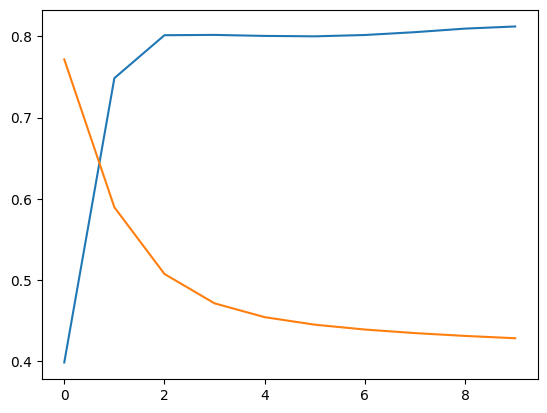

In [142]:
# Plot accuracy and loss
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['loss'])

## What changes can we make in the network to improve performance ?
1. Increase Epoch
2. Change Activation Function of any layer
3. Change Number of Nodes in Hidded layer
4. Increase Number of Hidden Layers (way more increase may lead to overfitting)

In [143]:
model2 = Sequential()
# Layer 0 Define the input shape explicitly
model2.add(Input(shape=(11,)))
# Layer 1
model2.add(Dense(11, activation = 'relu'))
# Layer 2
model2.add(Dense(11, activation = 'relu'))
# Layer 3 output layer
model2.add(Dense(1, activation = 'sigmoid'))


# compile the model (define loss function, optimizer)
model.compile(loss = 'binary_crossentropy', optimizer = 'Adam', metrics = ['accuracy'])

# Training with cross validation
history = model.fit(X_train_scaled, y_train, epochs = 100, validation_split = 0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8163 - loss: 0.4251 - val_accuracy: 0.8156 - val_loss: 0.4286
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8191 - loss: 0.4230 - val_accuracy: 0.8163 - val_loss: 0.4267
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8197 - loss: 0.4213 - val_accuracy: 0.8156 - val_loss: 0.4251
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8194 - loss: 0.4196 - val_accuracy: 0.8156 - val_loss: 0.4236
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8195 - loss: 0.4182 - val_accuracy: 0.8163 - val_loss: 0.4220
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8214 - loss: 0.4167 - val_accuracy: 0.8188 - val_loss: 0.4206
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8234 - loss: 0.4152 - val_accuracy: 0.8213 - val_loss: 0.4189
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8216 - loss: 0.4138 - val_accu

In [144]:
# If training accuracy increases but validation accuracy remains similar then its case of overfitting

In [145]:
y_log2 = model.predict(X_test_scaled)
y_pred2 = np.where(y_log2 > 0.5, 1, 0)
accuracy_score(y_test, y_pred2)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


0.857

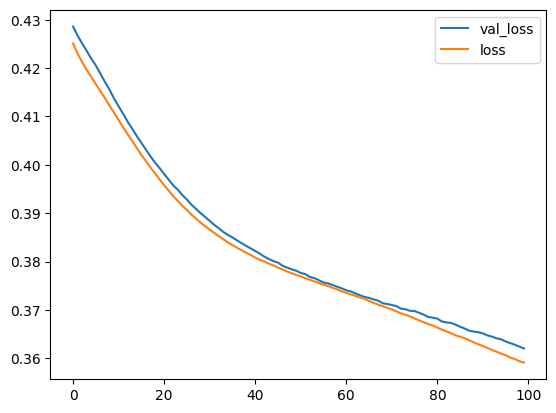

In [152]:
# check loss curves
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.plot(history.history['loss'], label = 'loss')
plt.legend()
plt.show()

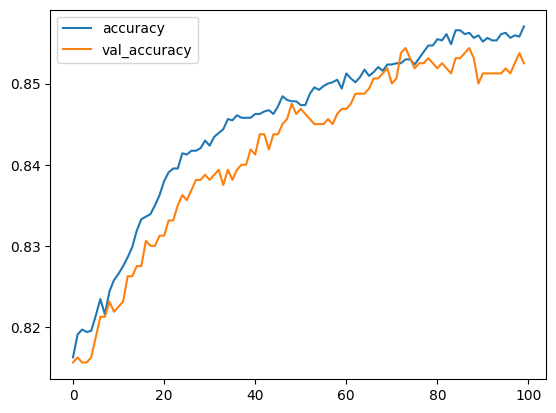

In [151]:
# check accuracy curves
plt.plot(history.history['accuracy'], label = 'accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.legend()
plt.show()